In [1]:
import numpy as np

def generate_spiral(n_points, noise=0.001):
    n = np.sqrt(np.random.rand(n_points)) * 780 * (2 * np.pi) / 360
    
    d1x = -np.cos(n) * n + np.random.rand(n_points) * noise
    d1y =  np.sin(n) * n + np.random.rand(n_points) * noise

    d2x =  np.cos(n) * n + np.random.rand(n_points) * noise
    d2y = -np.sin(n) * n + np.random.rand(n_points) * noise

    X = np.concatenate((np.vstack((d1x, d1y)).T,
                        np.vstack((d2x, d2y)).T))
    y = np.concatenate((np.zeros(n_points),
                        np.ones(n_points)))

    return X, y



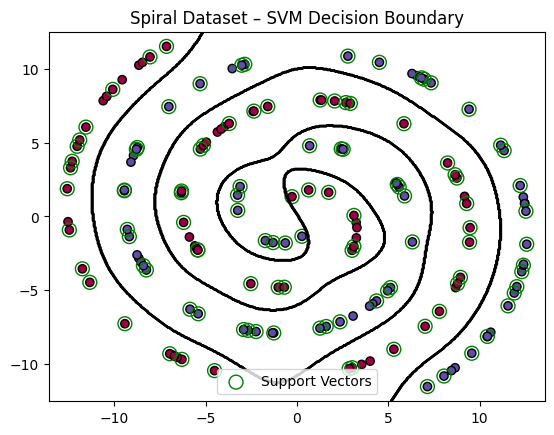

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
import numpy as np
import matplotlib.pyplot as plt


X, y = generate_spiral(100)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


clf = SVC(kernel='rbf', C=1, gamma=0.1)
clf.fit(X_train, y_train)

x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)


plt.contour(xx, yy, Z, alpha=0.8, colors='black')
plt.scatter(X_train[:, 0], X_train[:, 1],
            c=y_train, cmap=plt.cm.Spectral, edgecolors='k')

plt.scatter(clf.support_vectors_[:, 0],
            clf.support_vectors_[:, 1],
            facecolors='none', edgecolors='green',
            s=100, label='Support Vectors')

plt.title("Spiral Dataset – SVM Decision Boundary")
plt.legend()
plt.show()
